<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/EP3_Mineria_Datos_Abandono_Clientes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/EP3_Mineria_Datos_Abandono_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minería de Datos — Evaluación Sumativa 3 (EP3)
## Abandono de Clientes — Segmento RESIDENCIAL — Telcom
### Metodología CRISP-DM (Fases 1 a 5)

**Asignatura:** BIY7121 — Minería de Datos · Duoc UC
**Integrante(s):** NICOLAS ESTEBAN SILVA CARDENAS
**Docente:** PABLO SILVA
**Fecha:** 22/06/2026

---



## 0. Configuración del entorno e importación de librerías

### 0.1 Librerías utilizadas
En este bloque importo todas las librerías del proyecto. Uso **pandas** y **numpy** para el manejo y transformación de los datos, **matplotlib** y **seaborn** para las visualizaciones. Para el aprendizaje supervisado importo desde **scikit-learn** los tres clasificadores (`LogisticRegression`, `DecisionTreeClassifier`, `GaussianNB`) junto con las métricas de evaluación (accuracy, precision, recall, F1 y ROC-AUC). Para el no supervisado traigo `KMeans` y `AgglomerativeClustering`, la métrica `silhouette_score` y el `linkage`/`dendrogram` de scipy para el clustering jerárquico. Finalmente, desde **mlxtend** importo `apriori` y `association_rules` para las reglas de asociación. Fijo `RANDOM_STATE = 42` para que todos los resultados sean reproducibles.

In [ ]:
# Instalamos mlxtend (Apriori). El resto ya viene en Colab.
!pip install mlxtend --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos supervisados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

# Modelos no supervisados
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.ensemble import IsolationForest

# Reglas de asociación
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42
print("Librerías cargadas ✓")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Librerías cargadas ✓


## 1. Carga del dataset


### 1.1 Carga del dataset
Cargo el archivo `Abandono_Clientes.csv` montando Google Drive. Es importante usar el separador `;` (el archivo está delimitado por punto y coma, no por coma) y la codificación `utf-8-sig` para que lea correctamente los acentos y caracteres especiales de las comunas. Verifico la carga imprimiendo las dimensiones del dataset.

In [ ]:

df = pd.read_csv(ruta, sep=';', encoding='utf-8-sig', low_memory=False)
print("Dimensiones:", df.shape)
df.head(3)

Dimensiones: (180275, 84)


,SEGMENTO,EMPRESA,RUT_CLIENTE,FECHA,SS_SVATI,SS_INTE,SS_SVA,SS_DATOS,SS_TV,SS_MOVIL,...,FIDELIZADO,DERIVADO_A_EJECUTIVO,FECHA_CONTACTO,CODIGO_INE_COMUNA,COMUNA,PROVINCIA,REGION,SUPERFICIE_KM2,LATITUD_DECIMAL,LONGITUD_DECIMAL
0,RESIDENCIAL,TELCOM,MASKED,2024-03-31,0,1,0,0,0,0,...,NO,NO,NaN,10301.0,OSORNO,Osorno,Los Lagos,951.0,-40.5739,-73.1258
1,NEGOCIOS,TELCOM,MASKED,2024-03-31,0,1,1,0,0,0,...,NO,NO,NaN,6101.0,RANCAGUA,Cachapoal,Lib. Gral. Bernardo O' Higgins,260.3,-34.1619,-70.7408
2,NEGOCIOS,TELCOM,MASKED,2024-03-31,0,1,0,0,0,0,...,NO,NO,NaN,9108.0,LAUTARO,Cautín,La Araucanía,901.1,-38.5289,-72.4269


---
# FASE 1 — Comprensión del Negocio (Business Understanding)
**ANÁLISIS:**

- **Problema central:** Las empresas Telcom y Telcom_Aysen buscan reducir la pérdida de clientes producto del abandono voluntario de servicios. El dataset contiene información de clientes residenciales y negocios al 31 de marzo de 2024, junto con información de abandonos ocurridos entre mayo y julio de 2024. La organización requiere identificar anticipadamente a los clientes con mayor riesgo de abandonar completamente sus servicios para implementar estrategias de retención oportunas.
- **Impacto financiero/de mercado:** El abandono de clientes genera una disminución directa de los ingresos recurrentes de la compañía y aumenta los costos asociados a campañas de captación de nuevos clientes. Además, una alta tasa de abandono puede afectar la participación de mercado, la estabilidad de la cartera de clientes y la rentabilidad del negocio. La identificación temprana de clientes en riesgo permite focalizar recursos comerciales y mejorar la fidelización.
- **Objetivo organizacional:** Desarrollar un modelo predictivo que permita identificar clientes con alta probabilidad de abandono total (ABANDONO_INTE), apoyando la toma de decisiones comerciales y la implementación de estrategias de retención más efectivas.

**Hipótesis de negocio:**
1. _H1: Los clientes que presentan una mayor cantidad de reclamos técnicos y comerciales tienen una mayor probabilidad de abandonar completamente los servicios.
2. _H2: Los clientes con menor antigüedad y menor contratación de servicios presentan una mayor probabilidad de abandono total.


---
# FASE 2 — Comprensión de los Datos (Data Understanding)

Filtramos el segmento elegido (**RESIDENCIAL**) y exploramos volumen, tipos y la variable objetivo.

### 2.1 Selección de segmento y variable objetivo
Filtro el dataset para quedarme **solo con el segmento RESIDENCIAL**, (trabajar un único segmento). Defino como variable objetivo `ABANDONO_INTE`, que corresponde al **abandono parcial del servicio de Internet** (el servicio principal del segmento residencial). Reviso su distribución para dimensionar el desbalance de clases, factor decisivo para la elección posterior de métricas.

In [ ]:
# Elegimos el segmento RESIDENCIAL
df = df[df['SEGMENTO'] == 'RESIDENCIAL'].copy()
print("Filas residenciales:", df.shape[0], "| Columnas:", df.shape[1])

# Variable objetivo: abandono PARCIAL de Internet
TARGET = 'ABANDONO_INTE'
print("\nDistribución de la variable objetivo", TARGET, ":")
print(df[TARGET].value_counts())
print("\nTasa de abandono: {:.2f}%".format(df[TARGET].mean()*100))

Filas residenciales: 163262 | Columnas: 84

Distribución de la variable objetivo ABANDONO_INTE :
ABANDONO_INTE
0    157886
1      5376
Name: count, dtype: int64

Tasa de abandono: 3.29%


### 2.2 Descripción estadística
Genero el resumen estadístico (`describe`) de las variables numéricas más relevantes (antigüedad, monto por servicio, valor neto, velocidad, etc.) para conocer rangos, medias y dispersión, e identificar de forma preliminar posibles valores atípicos.

In [ ]:
# Descripción estadística general de variables numéricas clave
cols_desc = ['ANTG_MESES_TODO','MONTO_POR_SS','VLOR_NETO_PROM','VELOCIDAD_BAJADA',
             'MESES_COBROS','NUM_IDEN_GRUPOFAC','EVENTOS_DISTINTOS','HORAS_TOTALES_RUT']
df[cols_desc].describe().T

,count,mean,std,min,25%,50%,75%,max
ANTG_MESES_TODO,163262.0,86.493575,85.020300,0.0,28.000000,59.000000,118.000000,471.000000
MONTO_POR_SS,163262.0,19504.752265,6736.033797,126.0,14822.784091,18437.666667,23547.681818,261595.333333
VLOR_NETO_PROM,163262.0,34062.733977,15644.728495,252.0,24047.295455,30815.181818,40531.386364,415055.909091
VELOCIDAD_BAJADA,163187.0,823.394609,143.199184,0.0,800.000000,900.000000,900.000000,2048.000000
MESES_COBROS,163262.0,10.525107,1.659791,1.0,11.000000,11.000000,11.000000,11.000000
NUM_IDEN_GRUPOFAC,163262.0,1.085170,0.321688,1.0,1.000000,1.000000,1.000000,9.000000
EVENTOS_DISTINTOS,163262.0,1.115710,0.818110,0.0,1.000000,1.000000,1.000000,13.000000
HORAS_TOTALES_RUT,163262.0,6.497208,6.733137,0.0,5.170000,5.170000,5.170000,224.050000


### 2.3 Revisión de valores faltantes
Calculo el porcentaje de nulos por columna para planificar la estrategia de limpieza de la Fase 3. Esto me permite distinguir entre columnas que se deben imputar, columnas donde el nulo tiene un significado (por ejemplo, sin reclamos) y columnas que conviene eliminar por estar prácticamente vacías.

In [ ]:
# % de nulos por columna (solo donde hay nulos) -> ayuda a planear la limpieza
nulos = (df.isna().mean()*100).sort_values(ascending=False)
nulos[nulos > 0].round(1)

,0
TASA_TRANSM_EQUIPO_24,100.0
LISTA_EQUIPOS,100.0
RANK_EQUIPO,100.0
TASA_TRANSM_EQUIPO_50,100.0
FECHA_CONTACTO,100.0
LISTA_CAUSAS_COMERCIAL_NO_TERRENO,96.8
LISTA_CAUSAS_TECNICO_TERRENO,82.2
LISTA_TIPO_RECLAMOS_TECNICO_TERRENO,82.2
LISTA_TIPO_RECLAMOS_TECNICO_NO_TERRENO,77.3
LISTA_CAUSAS_TECNICO_NO_TERRENO,77.3


### 2.4 Análisis exploratorio visual
Construyo cuatro gráficas para explorar la relación de las variables con el abandono: (1) el **balance de la variable objetivo**, que evidencia el desbalance; (2) un **boxplot de antigüedad** según abandono; (3) el **porcentaje de abandono por paquete de servicios** (`CRUCE_ACTIVO`); y (4) un **boxplot del valor neto promedio** según abandono. Estas visualizaciones alimentan los insights iniciales y la validación de las hipótesis planteadas en la Fase 1.

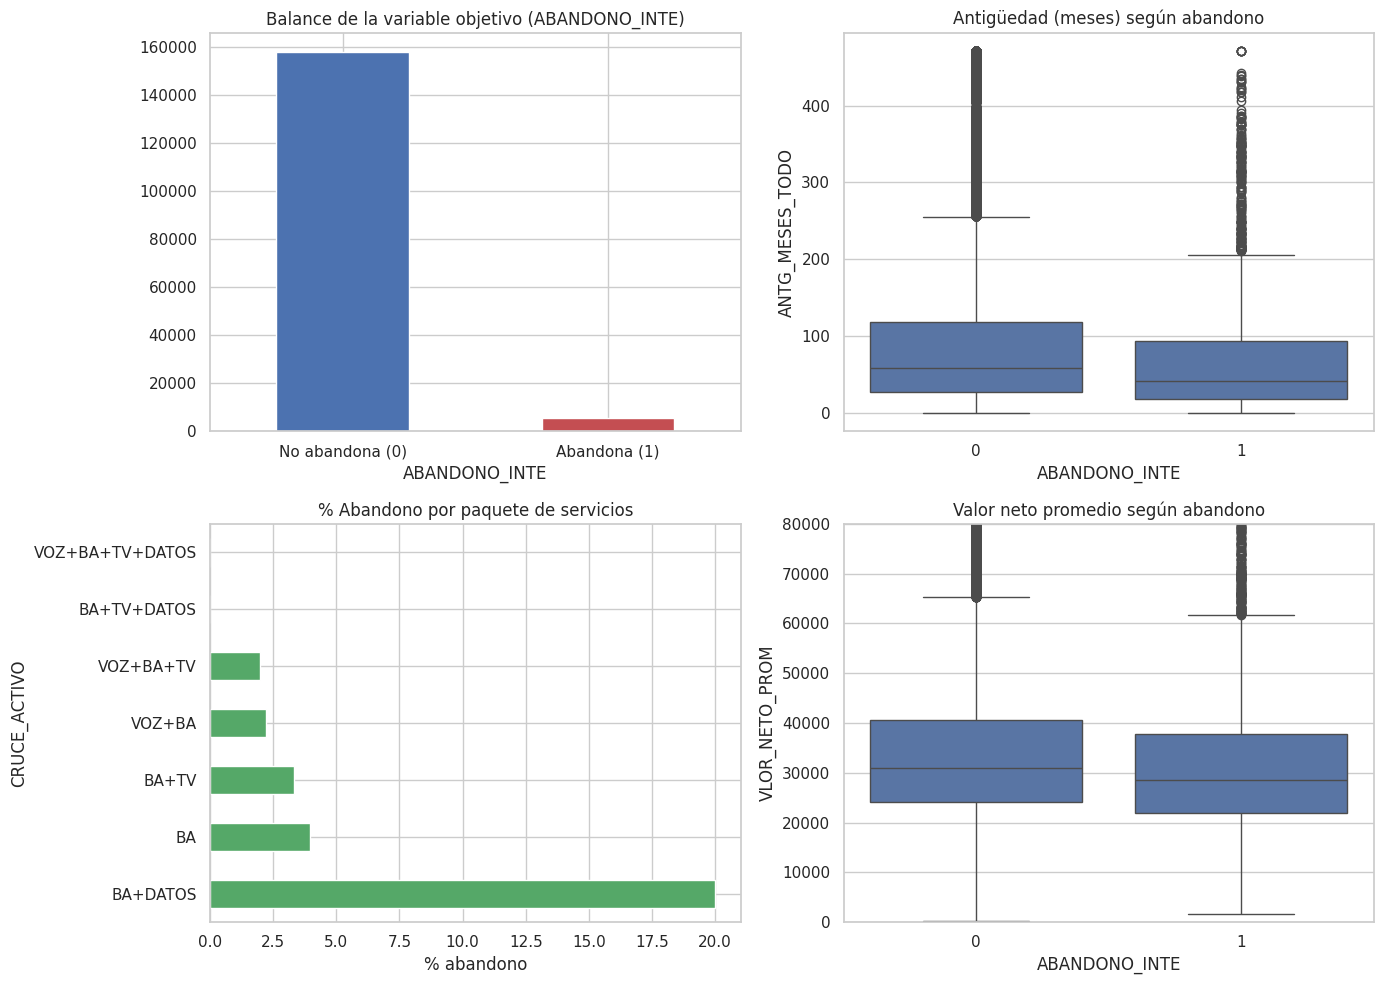

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Balance del target
df[TARGET].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4C72B0','#C44E52'])
axes[0,0].set_title('Balance de la variable objetivo (ABANDONO_INTE)')
axes[0,0].set_xticklabels(['No abandona (0)','Abandona (1)'], rotation=0)

# (2) Antigüedad vs abandono
sns.boxplot(x=TARGET, y='ANTG_MESES_TODO', data=df, ax=axes[0,1])
axes[0,1].set_title('Antigüedad (meses) según abandono')

# (3) Abandono por paquete activo (CRUCE_ACTIVO)
(df.groupby('CRUCE_ACTIVO')[TARGET].mean()*100).sort_values(ascending=False).head(8)\
  .plot(kind='barh', ax=axes[1,0], color='#55A868')
axes[1,0].set_title('% Abandono por paquete de servicios')
axes[1,0].set_xlabel('% abandono')

# (4) Valor neto promedio vs abandono
sns.boxplot(x=TARGET, y='VLOR_NETO_PROM', data=df, ax=axes[1,1])
axes[1,1].set_ylim(0, 80000)
axes[1,1].set_title('Valor neto promedio según abandono')

plt.tight_layout(); plt.show()

**ANÁLISIS (Insights iniciales):**

En el boxplot de antigüedad, los clientes que abandonan tienden a ser más nuevos que los que se quedan, ya que presentan una antigüedad promedio menor.
El paquete con mayor tasa de abandono es BA+DATOS, lo que sugiere que los clientes que contratan esta combinación de servicios presentan una mayor propensión a abandonar la compañía.
Los clientes que abandonan tienen un valor neto menor, lo que indica una menor vinculación económica con la empresa y posiblemente una menor fidelización hacia los servicios contratados.

Tasa de abandono global: **3,29%** (5.376 de 163.262 clientes residenciales), fuerte desbalance.
**interpretación:**
El análisis exploratorio muestra un fuerte desbalance en la variable objetivo, ya que los casos de abandono representan una proporción muy reducida respecto de los clientes que permanecen activos. Además, los clientes que abandonan presentan, en promedio, una menor antigüedad y un menor valor neto promedio que aquellos que permanecen en la compañía. Finalmente, se observan diferencias importantes entre los distintos paquetes de servicios, destacando el paquete BA+DATOS, que presenta la mayor tasa de abandono, lo que sugiere que la combinación de servicios contratados podría influir en la probabilidad de churn.
_..._


1. Balance de la variable objetivo (ABANDONO_INTE)

¿Qué muestra el gráfico?

La gran mayoría de los clientes pertenece a la categoría "No abandona".
Solo una pequeña proporción corresponde a clientes que sí abandonan el servicio.

Interpretación:

El gráfico evidencia un fuerte desbalance de clases, ya que los clientes que abandonan representan una proporción muy reducida respecto del total. Esto implica que los modelos predictivos podrían favorecer la clase mayoritaria, por lo que fue necesario aplicar técnicas de balanceo y utilizar métricas como Recall para evaluar correctamente la capacidad de detección de clientes en riesgo.

2. Antigüedad según abandono

¿Qué muestra el boxplot?

La mediana de antigüedad de los clientes que abandonan es menor que la de quienes permanecen.
Los clientes que se quedan tienden a acumular más tiempo en la empresa.

Interpretación:

Los clientes que abandonan tienden a ser más nuevos que aquellos que permanecen en la compañía. Esto sugiere que la antigüedad es un factor importante para la retención, ya que los clientes con relaciones comerciales más largas muestran una mayor estabilidad y fidelización.

3. % de abandono por paquete de servicios

¿Qué muestra el gráfico?

El paquete BA+DATOS presenta la tasa de abandono más alta.
Los demás paquetes muestran porcentajes considerablemente menores.

Interpretación:

El paquete BA+DATOS presenta la mayor tasa de abandono observada, cercana al 20%. Esto sugiere que los clientes que poseen esta combinación de servicios podrían estar menos satisfechos o tener una menor vinculación con la empresa, convirtiéndose en un segmento prioritario para futuras campañas de retención.

4. Valor neto promedio según abandono

¿Qué muestra el boxplot?

Los clientes que abandonan presentan un valor neto promedio ligeramente menor.
Existe una diferencia, aunque no extremadamente marcada.

Interpretación:

Los clientes que abandonan muestran un valor neto promedio algo menor que los clientes que permanecen. Esto podría indicar una menor vinculación económica con la empresa, ya que los clientes de menor valor tienden a ser más sensibles a cambios de precio, promociones de la competencia o insatisfacción con el servicio.

---
# FASE 3 — Preparación de los Datos (Data Preparation)

**Plan de limpieza (justifícalo con tus palabras en la celda de análisis):**
1. **Fuga de datos (leakage):** eliminamos TODAS las columnas `ABA_*` y los `ABANDONO_*` (salvo el target). Representan información futura que NO existiría al momento de predecir.
2. **Identificadores y fechas:** se eliminan (`RUT_CLIENTE`, nombres, fechas, códigos). La antigüedad ya está en `ANTG_MESES_TODO`.
3. **Columnas 100% vacías:** `RANK_EQUIPO`, `TASA_TRANSM_*` → se eliminan.
4. **Nulos:** `NUM_RECLAMOS*` (null = sin reclamos) → 0. Numéricas con pocos nulos → mediana. Categóricas → 'N'.
5. **Outliers:** detección por IQR en montos y capping (winsorize).
6. **Codificación:** `CRUCE_ACTIVO` (one-hot), binarias S/N → 0/1.
7. **Escalado:** `StandardScaler` para Reg. Logística y clustering.

### 3.1 Selección de variables (control de fuga de datos)
Selecciono las variables predictoras separándolas en numéricas, binarias y categóricas. **Punto crítico:** excluyo deliberadamente todas las columnas `ABA_*` y los demás indicadores `ABANDONO_*`, porque contienen información futura (posterior al 31-03-2024) que no estaría disponible al momento de hacer una predicción real. Incluirlas provocaría **fuga de datos (data leakage)** e inflaría artificialmente el desempeño de los modelos. También descarto identificadores, fechas y las columnas 100% vacías (`RANK_EQUIPO`, `TASA_TRANSM_*`).

In [ ]:
# --- 3.1 Selección de features (SIN columnas con fuga de datos) ---
features_num = ['SS_SVATI','SS_INTE','SS_SVA','SS_DATOS','SS_TV','SS_MOVIL','SS_TV_APP','SS_TEL',
                'ANTG_MESES_TODO','LOCALIDADES_DISTINTAS','MONTO_POR_SS','VELOCIDAD_SUBIDA',
                'VELOCIDAD_BAJADA','VLOR_NETO_PROM','MESES_COBROS','NUM_IDEN_GRUPOFAC',
                'NUM_RECLAMOS','NUM_RECLAMOS_TECNICO_TERRENO','EVENTOS_DISTINTOS','HORAS_TOTALES_RUT']

features_bin = ['FOX_SPORT_VIGENTE','OFFICE_VIGENTE','PLAN_HBO_VIGENTE','TNT_SPORT_VIGENTE',
                'PROVEEDOR_FINAL_ALARMCOM_VIGENTE','FOX_SPORT','OFFICE','PLAN_HBO','TNT_SPORT',
                'PROVEEDOR_FINAL_ALARMCOM','TELEVIGILANCIA']

features_cat = ['CRUCE_ACTIVO','EMPRESA','CONDICION_ESPECIAL','PRIORITARIO']

data = df[features_num + features_bin + features_cat + [TARGET]].copy()
print("Features seleccionadas:", data.shape[1]-1)

Features seleccionadas: 35


### 3.2 Imputación de valores faltantes
Trato los nulos según su naturaleza: en `NUM_RECLAMOS` y `NUM_RECLAMOS_TECNICO_TERRENO` el valor nulo significa que el cliente **no tuvo reclamos**, por lo que lo reemplazo por 0. El resto de las variables numéricas las imputo con la **mediana** (más robusta que la media frente a outliers), y las categóricas S/N con 'N'.

In [ ]:
# --- 3.2 Tratamiento de nulos ---
# Reclamos: null = el cliente no tuvo reclamos -> 0
for c in ['NUM_RECLAMOS','NUM_RECLAMOS_TECNICO_TERRENO']:
    data[c] = data[c].fillna(0)

# Numéricas restantes -> mediana
for c in features_num:
    data[c] = data[c].fillna(data[c].median())

# Categóricas S/N -> 'N'
for c in ['CONDICION_ESPECIAL','PRIORITARIO']:
    data[c] = data[c].fillna('N')

print("Nulos restantes:", int(data.isna().sum().sum()))

Nulos restantes: 0


### 3.3 Tratamiento de outliers
Defino una función de *capping* por **rango intercuartílico (IQR)**: los valores que caen fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR] se recortan al límite en lugar de eliminarse, conservando así el registro completo del cliente. Lo aplico a las variables de montos (`MONTO_POR_SS`, `VLOR_NETO_PROM`, `HORAS_TOTALES_RUT`), que presentaban valores extremos.

In [ ]:
# --- 3.3 Detección y tratamiento de outliers (IQR capping) en montos ---
def cap_iqr(serie, k=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return serie.clip(low, high), ((serie < low) | (serie > high)).sum()

for c in ['MONTO_POR_SS','VLOR_NETO_PROM','HORAS_TOTALES_RUT']:
    data[c], n_out = cap_iqr(data[c])
    print(f"{c}: {n_out} outliers acotados (capping)")

MONTO_POR_SS: 2490 outliers acotados (capping)
VLOR_NETO_PROM: 6334 outliers acotados (capping)
HORAS_TOTALES_RUT: 32481 outliers acotados (capping)


### 3.4 Codificación de variables
Transformo las variables categóricas a formato numérico para que los modelos puedan procesarlas: las binarias S/N pasan a 1/0, `EMPRESA` se vuelve binaria, y a `CRUCE_ACTIVO` (paquete de servicios) le aplico **one-hot encoding** con `get_dummies`. Finalmente fuerzo todo a tipo numérico.

In [ ]:
# --- 3.4 Codificación ---
# Binarias S/N -> 1/0
for c in ['CONDICION_ESPECIAL','PRIORITARIO']:
    data[c] = (data[c] == 'S').astype(int)
# EMPRESA -> binaria
data['EMPRESA'] = (data['EMPRESA'] == 'TELCOM_AYSEN').astype(int)
# CRUCE_ACTIVO -> one-hot
data = pd.get_dummies(data, columns=['CRUCE_ACTIVO'], prefix='PACK', drop_first=True)
# Asegurar tipo numérico
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)
print("Shape final tras codificación:", data.shape)

Shape final tras codificación: (163262, 41)


### 3.5 Partición y escalamiento
Separo las variables predictoras (X) de la objetivo (y) y divido en **entrenamiento (75%) y prueba (25%)** usando `stratify=y` para conservar la misma proporción de abandono en ambos conjuntos (clave por el desbalance). Aplico `StandardScaler` ajustándolo **solo con el train** y transformando el test, para evitar fuga de información del conjunto de prueba.

In [ ]:
# --- 3.5 Separación X / y, train/test y escalado ---
X = data.drop(columns=[TARGET])
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Tasa abandono train: {:.2f}% | test: {:.2f}%".format(y_train.mean()*100, y_test.mean()*100))

Train: (122446, 40) | Test: (40816, 40)
Tasa abandono train: 3.29% | test: 3.29%


**ANÁLISIS (obstáculos de la data):**

El principal obstáculo fue el fuerte desbalance de clases (solo 3,29% de abandono), que podía reducir la capacidad del modelo para detectar clientes en riesgo.
Para enfrentarlo se aplicó class_weight='balanced' en los modelos supervisados, imputación de valores nulos como 0 en variables de reclamos y eliminación de columnas con fuga de datos (ABA_ y ABANDONO_).

---
**datos reales:**
- Desbalance severo: solo **3,29%** de clase positiva.
- Columnas con fuga de datos eliminadas (`ABA_*`, otros `ABANDONO_*`).
- `RANK_EQUIPO` y `TASA_TRANSM_*` estaban 100% vacías; `NUM_RECLAMOS*` con ~65% de nulos (interpretados como "sin reclamos").

**Interpretación:**
El principal desafío identificado fue el fuerte desbalance de la variable objetivo, ya que solo el 3,29% de los registros corresponde a clientes que abandonaron el servicio. Además, se detectaron variables con fuga de información, particularmente las columnas relacionadas con abandonos futuros (ABA_* y otros indicadores de abandono), las cuales fueron eliminadas para evitar sesgos en el entrenamiento de los modelos. Finalmente, se encontraron columnas completamente vacías, como RANK_EQUIPO y TASA_TRANSM_, y variables con una alta proporción de valores nulos, como NUM_RECLAMOS, que requirieron un tratamiento adecuado para preservar la calidad del análisis.
_..._


---
# FASE 4 — Modelado

## 4.A Aprendizaje Supervisado — Predicción de Abandono Parcial
Tres modelos: **Regresión Logística**, **Árbol de Decisión** y **Naive Bayes**.
Usamos `class_weight='balanced'` donde aplica, por el fuerte desbalance (~3% de churn).

### 4.1 Entrenamiento de los modelos supervisados
Entreno los **tres modelos** definidos: Regresión Logística, Árbol de Decisión y Naive Bayes. En la Regresión Logística y el Árbol uso `class_weight='balanced'` para compensar el fuerte desbalance (~3% de abandono); sin esto, los modelos tenderían a predecir siempre la clase mayoritaria. La Regresión Logística y Naive Bayes se entrenan con los datos **escalados**, mientras que el Árbol no lo requiere por ser invariante a la escala. Guardo predicciones y probabilidades de cada modelo y calculo las cinco métricas en una tabla comparativa.

In [ ]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'Árbol de Decisión'  : DecisionTreeClassifier(max_depth=6, class_weight='balanced',
                                                  random_state=RANDOM_STATE),
    'Naive Bayes'        : GaussianNB()
}

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    # LogReg y NB rinden mejor con datos escalados; el árbol no lo necesita
    if nombre == 'Árbol de Decisión':
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        modelo.fit(X_train_sc, y_train)
        y_pred = modelo.predict(X_test_sc)
        y_proba = modelo.predict_proba(X_test_sc)[:, 1]

    predicciones[nombre] = (y_pred, y_proba)
    resultados.append({
        'Modelo'   : nombre,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').round(3)
tabla

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.493,0.045,0.706,0.084,0.637
Árbol de Decisión,0.533,0.044,0.638,0.083,0.621
Naive Bayes,0.114,0.035,0.990,0.068,0.540


### 4.2 Comparación visual de métricas
Grafico en barras las cinco métricas de los tres modelos para compararlas de un vistazo y facilitar la posterior selección del modelo ganador.

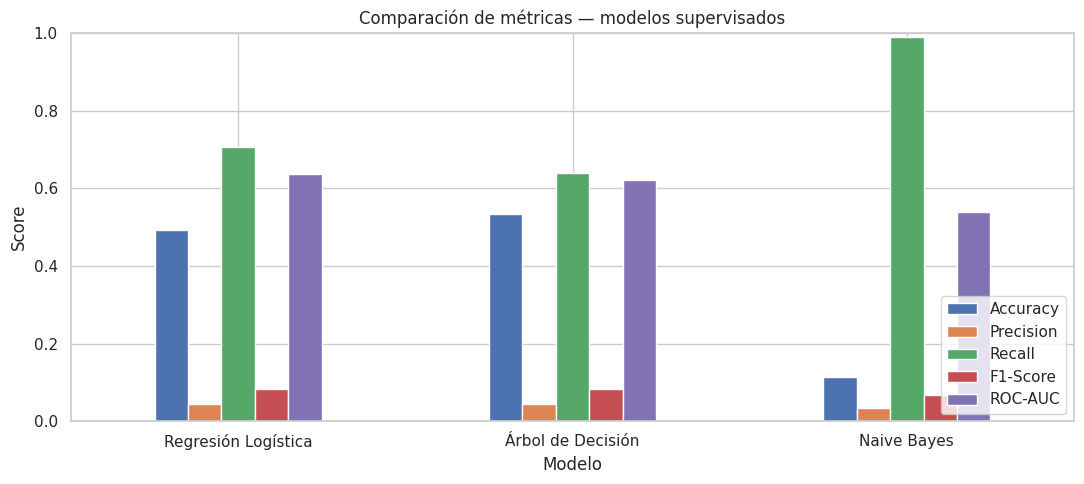

In [ ]:
# Tabla comparativa visual
tabla.plot(kind='bar', figsize=(11,5))
plt.title('Comparación de métricas — modelos supervisados')
plt.ylabel('Score'); plt.ylim(0,1); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

### 4.3 Matrices de confusión
Genero la matriz de confusión de cada modelo. Es la base para el análisis de negocio: permite cuantificar los **Falsos Negativos** (clientes que se van y no detecté) frente a los **Falsos Positivos** (clientes que retengo innecesariamente), que tienen costos distintos para la empresa.

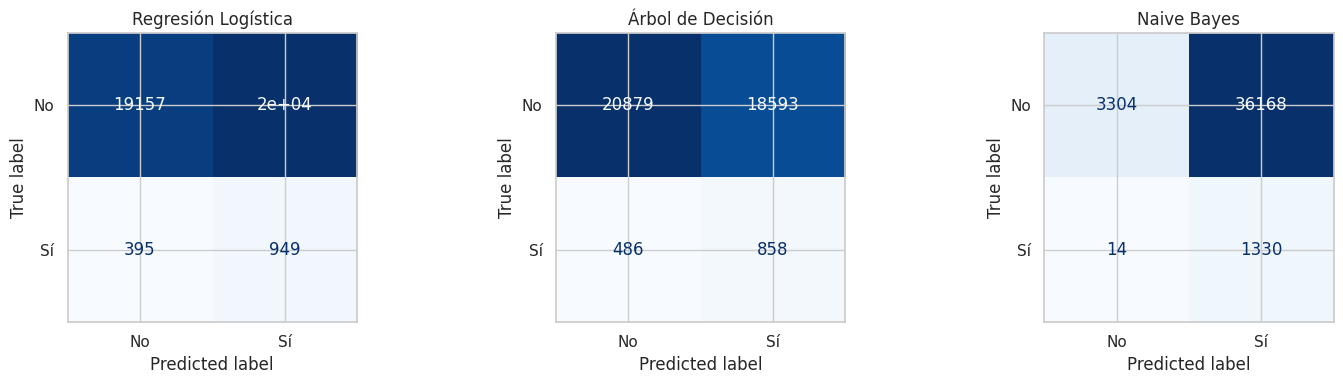

In [ ]:
# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, (y_pred, _)) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No','Sí']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.tight_layout(); plt.show()

### 4.4 Curvas ROC
Trazo la curva ROC de cada modelo con su AUC. El ROC-AUC mide la capacidad de discriminación independientemente del umbral de decisión, lo que lo hace ideal para comparar modelos sobre datos desbalanceados.

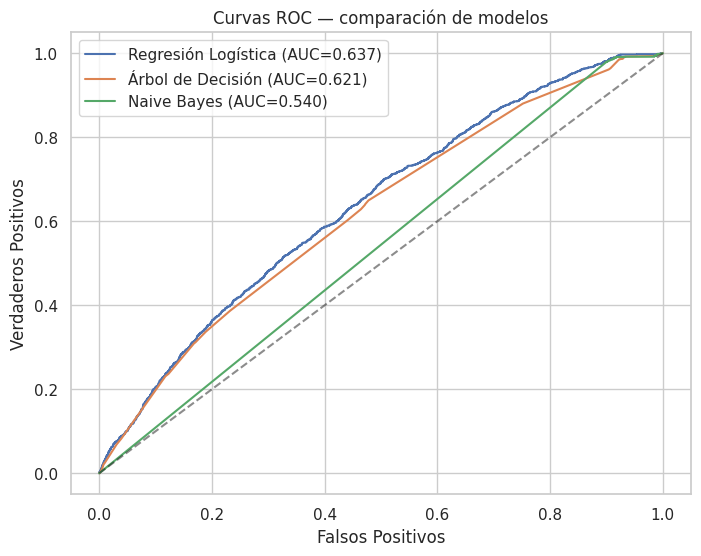

In [ ]:
# Curvas ROC
plt.figure(figsize=(8,6))
for nombre, (_, y_proba) in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=.5)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title('Curvas ROC — comparación de modelos'); plt.legend(); plt.show()

### 4.5 Variables más influyentes
Extraigo los coeficientes de la Regresión Logística para identificar qué variables **empujan** y cuáles **frenan** la probabilidad de abandono. Esto aporta interpretabilidad y sirve para contrastar las hipótesis de negocio de la Fase 1.

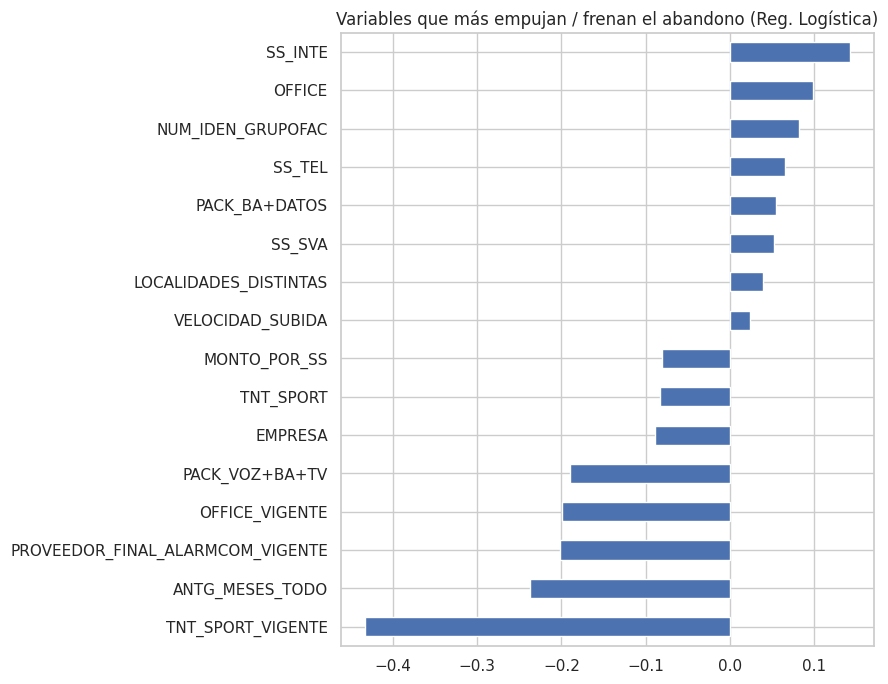

In [ ]:
# Variables más influyentes (coeficientes de Regresión Logística)
logit = modelos['Regresión Logística']
imp = pd.Series(logit.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(9,7))
pd.concat([imp.head(8), imp.tail(8)]).plot(kind='barh', color='#4C72B0')
plt.title('Variables que más empujan / frenan el abandono (Reg. Logística)')
plt.tight_layout(); plt.show()

**ANÁLISIS — Selección del mejor modelo:**

- En churn, ¿qué es más caro: un **Falso Positivo** (gastar campaña en quien no se iba) o un **Falso Negativo** (perder a quien sí se iba)? → En este problema de churn, el error más costoso para Telcom corresponde a un Falso Negativo, ya que significa no identificar a un cliente que realmente abandonará la compañía. Esto provoca una pérdida directa de ingresos y elimina la posibilidad de aplicar acciones de retención. Por este motivo, la métrica más importante es el Recall, ya que busca detectar la mayor cantidad posible de clientes en riesgo.
- Según ese criterio y la tabla/ROC, **¿cuál modelo eligen y por qué?**
Al comparar los modelos, Naive Bayes obtuvo el Recall más alto (0,990), pero presentó un ROC-AUC considerablemente inferior (0,540), lo que indica una baja capacidad de discriminación general. Por otro lado, la Regresión Logística alcanzó el mejor equilibrio entre detección de clientes en riesgo y capacidad predictiva global, obteniendo un Recall de 0,706 y el mayor ROC-AUC (0,637). Por esta razón, se selecciona como el modelo más adecuado para apoyar la toma de decisiones de negocio.
- ¿Tus hipótesis de la Fase 1 se confirman al ver las variables influyentes?
Respecto a las hipótesis planteadas en la Fase 1, los resultados sugieren que variables como la antigüedad y los reclamos tienen influencia sobre el abandono. Los clientes con menor antigüedad presentan una mayor tendencia a abandonar los servicios, mientras que una mayor cantidad de reclamos se asocia con un incremento en el riesgo de churn, validando parcialmente las hipótesis definidas inicialmente.
---
📊 **Tus métricas reales (de tu corrida):**

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Regresión Logística | 0.493 | 0.045 | 0.706 | 0.084 | **0.637** |
| Árbol de Decisión | 0.533 | 0.044 | 0.638 | 0.083 | 0.621 |
| Naive Bayes | 0.114 | 0.035 | **0.990** | 0.068 | 0.540 |

**interpretación:**
En este caso de negocio, resulta más costoso cometer un Falso Negativo, ya que implica no identificar a un cliente que efectivamente abandonará la compañía, perdiendo la oportunidad de aplicar acciones de retención. Por esta razón, se prioriza la métrica Recall, que permite detectar la mayor cantidad posible de clientes en riesgo. Aunque Naive Bayes obtuvo el Recall más alto, su capacidad de discriminación general fue baja. La Regresión Logística presentó el mejor equilibrio entre Recall y desempeño global, alcanzando el mayor ROC-AUC (0,637), por lo que se considera el modelo más adecuado para apoyar la toma de decisiones. Además, los resultados respaldan las hipótesis planteadas inicialmente, evidenciando que la menor antigüedad y la presencia de reclamos se asocian con una mayor probabilidad de abandono.
_..._


---
## 4.B Aprendizaje No Supervisado — Segmentación de Clientes

### Modelo 1: K-Means
Buscamos el número óptimo de clústeres con el **método del codo** y el **Silhouette Score**.

### 4.6 Búsqueda del número óptimo de clústeres (K-Means)
Selecciono un subconjunto de variables de perfilamiento del cliente (antigüedad, montos, servicios, reclamos, velocidad) y las escalo. Luego barro valores de k de 2 a 8 calculando la **inercia** (método del codo) y el **Silhouette Score**, para determinar el número de grupos que mejor estructura los datos.

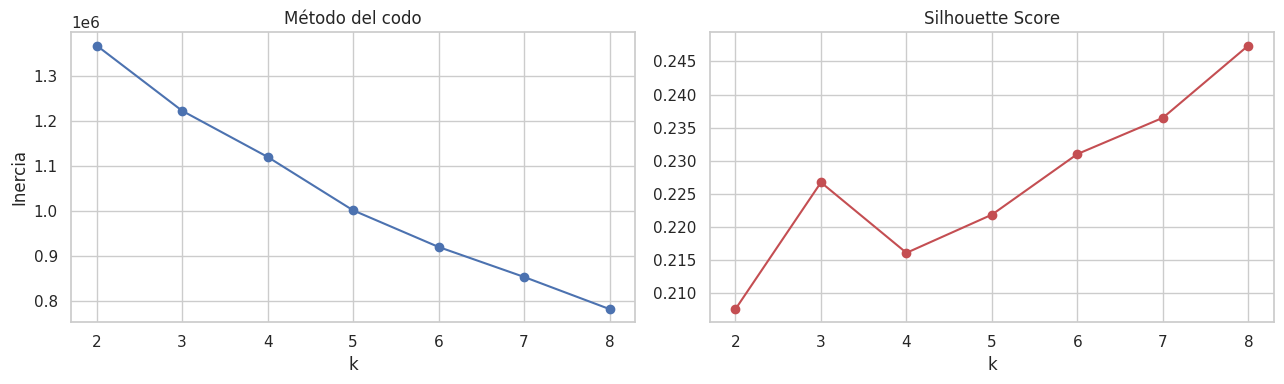

In [ ]:
# Variables para segmentar
cols_seg = ['ANTG_MESES_TODO','MONTO_POR_SS','VLOR_NETO_PROM','SS_INTE','SS_TV','SS_MOVIL',
            'SS_SVA','NUM_RECLAMOS','EVENTOS_DISTINTOS','VELOCIDAD_BAJADA']
X_seg = StandardScaler().fit_transform(data[cols_seg])

inercia, sils = [], []
rango_k = range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_seg)
    inercia.append(km.inertia_)
    sils.append(silhouette_score(X_seg, km.labels_, sample_size=10000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(list(rango_k), inercia, 'o-'); ax[0].set_title('Método del codo'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia')
ax[1].plot(list(rango_k), sils, 'o-', color='#C44E52'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

### 4.7 Ajuste de K-Means
Ajusto el modelo K-Means con el número de clústeres elegido a partir del análisis anterior y asigno la etiqueta de grupo a cada cliente. Reporto el Silhouette final y el tamaño de cada clúster.

In [ ]:
# (codo + silhouette)
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_seg)
data['CLUSTER'] = kmeans.labels_
print("Silhouette final:", round(silhouette_score(X_seg, kmeans.labels_, sample_size=10000, random_state=RANDOM_STATE),3))
print(data['CLUSTER'].value_counts().sort_index())

Silhouette final: 0.216
CLUSTER
0     8734
1    73089
2    32507
3    48932
Name: count, dtype: int64


### 4.8 Perfilamiento de clústeres
Calculo el promedio de cada variable por clúster y agrego la **tasa de abandono** y el **número de clientes** de cada grupo. Esta tabla es la base para caracterizar y nombrar cada segmento.

In [ ]:
# Perfilado de clústeres: promedio de cada variable por grupo + tasa de abandono
perfil = data.groupby('CLUSTER')[cols_seg].mean().round(1)
perfil['TASA_ABANDONO_%'] = (data.groupby('CLUSTER')[TARGET].mean()*100).round(2)
perfil['N_CLIENTES'] = data['CLUSTER'].value_counts().sort_index()
perfil

,ANTG_MESES_TODO,MONTO_POR_SS,VLOR_NETO_PROM,SS_INTE,SS_TV,SS_MOVIL,SS_SVA,NUM_RECLAMOS,EVENTOS_DISTINTOS,VELOCIDAD_BAJADA,TASA_ABANDONO_%,N_CLIENTES
CLUSTER,,,,,,,,,,,,
0,123.6,18834.4,55618.4,2.1,1.0,0.0,0.6,1.1,1.2,876.3,5.82,8734
1,118.0,17290.1,39520.1,1.0,1.0,0.0,0.3,0.7,1.1,889.8,2.47,73089
2,47.7,17623.3,25336.5,1.0,0.3,0.0,0.1,0.5,1.0,574.7,4.24,32507
3,58.6,23793.0,25421.2,1.0,0.0,0.0,0.2,0.4,1.1,880.2,3.44,48932


### 4.9 Mapa de calor de perfiles
Estandarizo los promedios por clúster y los grafico en un heatmap para comparar visualmente qué variables caracterizan a cada grupo y distinguirlos entre sí.

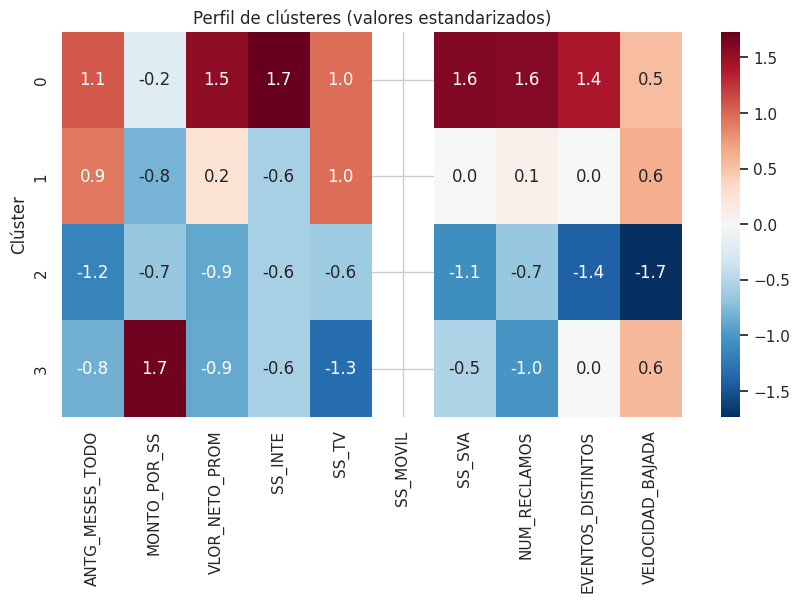

In [ ]:
# Mapa de calor del perfil (estandarizado) para comparar grupos de un vistazo
from scipy.stats import zscore
plt.figure(figsize=(10,5))
sns.heatmap(perfil[cols_seg].apply(zscore), annot=True, cmap='RdBu_r', center=0, fmt='.1f')
plt.title('Perfil de clústeres (valores estandarizados)'); plt.ylabel('Clúster'); plt.show()

**ANÁLISIS:**

Clúster 0: Clientes Premium Multiservicio de Alto Valor

Este grupo presenta la mayor antigüedad promedio (123,6 meses), el mayor valor neto ($55.618) y la mayor cantidad de servicios contratados. También registra la mayor cantidad de reclamos, lo que indica una alta interacción con la empresa. Sin embargo, presenta la tasa de abandono más alta (5,82%), por lo que corresponde al segmento más valioso y, al mismo tiempo, el más crítico para implementar estrategias de retención.

Clúster 1: Clientes Consolidados y Estables

Corresponde al grupo más numeroso de clientes. Presentan alta antigüedad (118 meses), valor neto medio-alto y una combinación estable de servicios de Internet y televisión. Además, registran la menor tasa de abandono (2,47%), lo que los convierte en el segmento más estable de la cartera.

Clúster 2: Clientes Nuevos de Bajo Valor

Son clientes con menor antigüedad (47,7 meses), menor valor neto promedio y menor contratación de servicios complementarios. Aunque poseen una tasa de abandono relevante (4,24%), su principal característica es la baja consolidación de la relación comercial con la empresa.

Clúster 3: Clientes Básicos de Internet

Este segmento se caracteriza por contratar principalmente Internet, con poca presencia de servicios adicionales. Presentan una antigüedad intermedia (58,6 meses) y una tasa de abandono de 3,44%, superior a la de los clientes consolidados, pero inferior a la observada en los grupos de mayor riesgo.

Grupo de mayor riesgo de abandono

De acuerdo con la variable TASA_ABANDONO_%, el grupo con mayor riesgo es el Clúster 0, que alcanza una tasa de abandono de 5,82%. Aunque corresponde a los clientes más antiguos y rentables, también son los que abandonan con mayor frecuencia, por lo que representan el segmento prioritario para las estrategias de retención. El segundo grupo de mayor riesgo corresponde al Clúster 2, con una tasa de abandono de 4,24%.

---
📊 **clústeres (K-Means, k=4):**

| Clúster | N° clientes | Antigüedad | Valor neto | SS_INTE | SS_TV | Reclamos |
|---|---|---|---|---|---|---|
| 0 | 8.734 | 123,6 | 55.618 | 2,1 | 1,0 | 1,1 |
| 1 | 73.089 | 118,0 | 39.520 | 1,0 | 1,0 | 0,7 |
| 2 | 32.507 | 47,7 | 25.336 | 1,0 | 0,3 | 0,5 |
| 3 | 48.932 | 58,6 | 25.421 | 1,0 | 0,0 | 0,4 |

Silhouette = 0.216.
Clúster 0: Clientes Premium Multiservicio de Alto Valor. Son clientes con la mayor antigüedad, mayor valor neto y mayor cantidad de servicios contratados. Aunque representan la cartera más valiosa para la empresa, también presentan la tasa de abandono más alta.
Clúster 1: Clientes Consolidados y Estables. Corresponden al grupo más numeroso, con alta antigüedad, servicios consolidados de Internet y TV, y la menor tasa de abandono, lo que los convierte en el segmento más estable.
Clúster 2: Clientes Nuevos de Bajo Valor. Se caracterizan por su menor antigüedad, menor valor neto promedio y menor contratación de servicios complementarios. Presentan una tasa de abandono relativamente alta y una menor vinculación con la empresa.
Clúster 3: Clientes Básicos de Internet. Son clientes con pocos servicios contratados, principalmente Internet, valor neto moderado y una tasa de abandono intermedia. Su nivel de fidelización es menor que el de los clientes consolidados.

Grupo de mayor riesgo: El Clúster 0 (Clientes Premium Multiservicio de Alto Valor) presenta la mayor tasa de abandono (5,82%), por lo que constituye el segmento de mayor riesgo y debe ser priorizado en las estrategias de retención debido a su alto valor para la compañía.


### Modelo 2: Clustering Jerárquico (investigado)
Es O(n²) en memoria, así que se aplica sobre una **muestra** representativa.

### 4.10 Clustering jerárquico — dendrograma
Como el clustering jerárquico tiene un costo computacional O(n²) en memoria, lo aplico sobre una **muestra aleatoria de 3.000 clientes** representativa. Construyo el dendrograma con el método **Ward** (minimiza la varianza intra-clúster) para visualizar la estructura jerárquica y decidir el punto de corte.

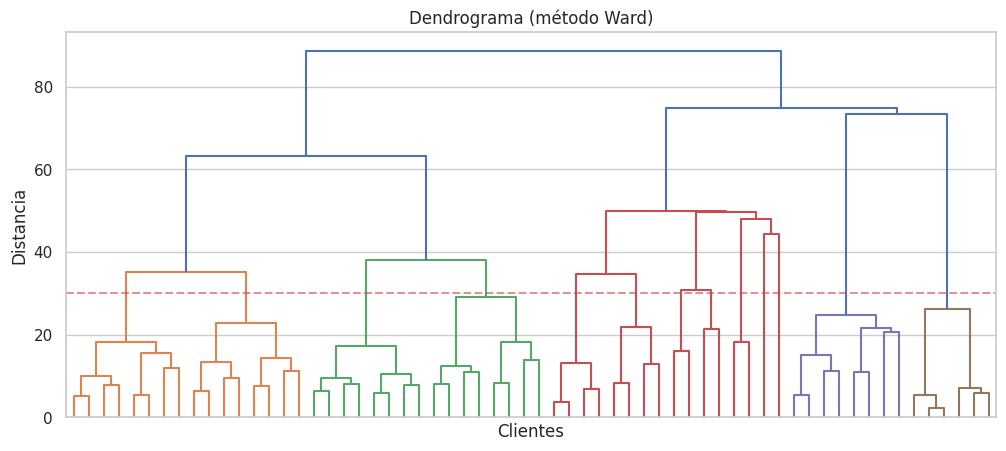

In [ ]:
# Muestra aleatoria para el jerárquico (3000 clientes)
muestra = data.sample(3000, random_state=RANDOM_STATE)
X_m = StandardScaler().fit_transform(muestra[cols_seg])

# Dendrograma
plt.figure(figsize=(12,5))
Z = linkage(X_m, method='ward')
dendrogram(Z, truncate_mode='level', p=5, no_labels=True)
plt.title('Dendrograma (método Ward)'); plt.xlabel('Clientes'); plt.ylabel('Distancia')
plt.axhline(y=30, color='r', linestyle='--', alpha=.6)  # TODO TÚ: ajusta el corte
plt.show()

### 4.11 Ajuste del clustering jerárquico
Ajusto `AgglomerativeClustering` con el número de grupos sugerido por el dendrograma y comparo su Silhouette y sus perfiles con los de K-Means, para evaluar cuál entrega segmentos más interpretables.

In [ ]:
# Clustering jerárquico con el nº de grupos que sugiere el dendrograma
K_JER = 4   # TODO TÚ: ajusta según el corte del dendrograma
agg = AgglomerativeClustering(n_clusters=K_JER, linkage='ward').fit(X_m)
muestra = muestra.copy(); muestra['CLUSTER_JER'] = agg.labels_
print("Silhouette jerárquico:", round(silhouette_score(X_m, agg.labels_),3))
muestra.groupby('CLUSTER_JER')[cols_seg].mean().round(1)

Silhouette jerárquico: 0.191


,ANTG_MESES_TODO,MONTO_POR_SS,VLOR_NETO_PROM,SS_INTE,SS_TV,SS_MOVIL,SS_SVA,NUM_RECLAMOS,EVENTOS_DISTINTOS,VELOCIDAD_BAJADA
CLUSTER_JER,,,,,,,,,,
0,58.0,21267.0,25727.9,1.0,0.1,0.0,0.2,0.3,1.0,757.9
1,208.4,13247.4,47658.3,1.1,0.7,1.3,0.4,0.3,1.0,827.3
2,113.5,17425.9,37734.7,1.0,0.9,0.0,0.3,0.9,1.2,877.1
3,121.9,18540.2,54363.2,2.1,0.9,0.0,0.6,1.0,1.2,871.1


**ANÁLISIS — K-Means vs Jerárquico:**

---
- Silhouette K-Means = **0.216** | Silhouette Jerárquico = **0.191**.
- El jerárquico (sobre muestra de 3.000) también separó un grupo antiguo de alto valor y otro nuevo de bajo valor, similar a K-Means.

**¿coinciden? ¿cuál es más interpretable y por qué?:**
Ambos métodos generaron segmentos similares y permitieron distinguir grupos de clientes con diferentes niveles de antigüedad, valor y contratación de servicios. No obstante, K-Means obtuvo un mejor índice Silhouette (0,216 frente a 0,191), indicando una mejor calidad de agrupamiento. Además, sus resultados son más fáciles de interpretar y utilizar para diseñar estrategias comerciales, por lo que se selecciona como la mejor alternativa de segmentación.
_..._


### 4.12 Detección de outliers (Isolation Forest)
Aplico `IsolationForest` con una contaminación del 2% para detectar clientes atípicos en el espacio de perfilamiento. Comparo el perfil de los clientes atípicos frente a los normales, cubriendo el requisito de detección de outliers del bloque no supervisado.

In [ ]:
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE).fit(X_seg)
data['OUTLIER'] = (iso.predict(X_seg) == -1).astype(int)
print("Clientes atípicos detectados:", int(data['OUTLIER'].sum()),
      f"({data['OUTLIER'].mean()*100:.1f}%)")
data.groupby('OUTLIER')[['MONTO_POR_SS','VLOR_NETO_PROM','ANTG_MESES_TODO',TARGET]].mean().round(1)

Clientes atípicos detectados: 3266 (2.0%)


,MONTO_POR_SS,VLOR_NETO_PROM,ANTG_MESES_TODO,ABANDONO_INTE
OUTLIER,,,,
0,19408.9,32841.3,84.7,0.0
1,18368.2,57349.4,173.2,0.0


---
## 4.C Reglas de Asociación — Apriori (cross-selling)
Descubrimos qué servicios se contratan juntos, para diseñar "anclas" de fidelización.

### 4.13 Construcción de transacciones (Apriori)
Para las reglas de asociación transformo cada cliente en una **canasta de servicios** que posee (Internet, TV, Telefonía, Móvil, SVA, etc.). Me quedo con las canastas de 2 o más ítems y las codifico con `TransactionEncoder` al formato booleano que requiere el algoritmo Apriori.

In [ ]:
# Construimos transacciones: cada cliente = canasta de servicios que posee
def canasta(row):
    items = []
    if row['SS_INTE']  > 0: items.append('Internet')
    if row['SS_TV']    > 0: items.append('TV')
    if row['SS_TEL']   > 0: items.append('Telefonia')
    if row['SS_MOVIL'] > 0: items.append('Movil')
    if row['SS_TV_APP']> 0: items.append('TV_App')
    if row['SS_SVA']   > 0: items.append('SVA')
    if row['SS_DATOS'] > 0: items.append('Datos')
    if row.get('TNT_SPORT_VIGENTE',0)==1: items.append('TNT_Sport')
    if row.get('OFFICE_VIGENTE',0)==1:    items.append('Office')
    if row.get('PLAN_HBO_VIGENTE',0)==1:  items.append('HBO')
    return items

transacciones = df.apply(canasta, axis=1).tolist()
transacciones = [t for t in transacciones if len(t) > 1]   # canastas con 2+ items
print("Transacciones válidas:", len(transacciones))

te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)
df_trans.head(3)

Transacciones válidas: 109020


,Datos,HBO,Internet,Movil,Office,SVA,TNT_Sport,TV,TV_App,Telefonia
0,False,False,True,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,True,False,True
2,False,False,True,False,False,False,False,True,False,True


### 4.14 Generación de reglas de asociación
Aplico **Apriori** con un soporte mínimo de 0.02 para encontrar los itemsets frecuentes y genero las reglas ordenadas por **lift**. Las métricas clave son soporte (frecuencia conjunta), confianza (probabilidad condicional) y lift (fuerza de la asociación frente al azar).

In [ ]:
# Itemsets frecuentes y reglas
frecuentes = apriori(df_trans, min_support=0.02, use_colnames=True)
reglas = association_rules(frecuentes, metric='lift', min_threshold=1.0)
reglas = reglas.sort_values('lift', ascending=False)

# Mostramos las reglas más fuertes
cols_show = ['antecedents','consequents','support','confidence','lift']
reglas[cols_show].head(12).round(3)

,antecedents,consequents,support,confidence,lift
80,"(Internet, TNT_Sport)","(Telefonia, TV)",0.038,0.420,1.557
81,"(Telefonia, TV)","(Internet, TNT_Sport)",0.038,0.139,1.557
87,(TNT_Sport),"(Internet, Telefonia, TV)",0.038,0.420,1.557
74,"(Internet, Telefonia, TV)",(TNT_Sport),0.038,0.139,1.557
53,(TNT_Sport),"(Telefonia, TV)",0.038,0.420,1.557
48,"(Telefonia, TV)",(TNT_Sport),0.038,0.139,1.557
40,"(SVA, TV)",(TNT_Sport),0.029,0.123,1.376
43,(TNT_Sport),"(SVA, TV)",0.029,0.324,1.376
59,"(SVA, TV)","(Internet, TNT_Sport)",0.029,0.123,1.376
58,"(Internet, TNT_Sport)","(SVA, TV)",0.029,0.324,1.376


### 4.15 Visualización de reglas
Grafico las reglas en un plano confianza vs lift (con el tamaño del punto proporcional al soporte) para identificar visualmente las asociaciones más fuertes y accionables para cross-selling.

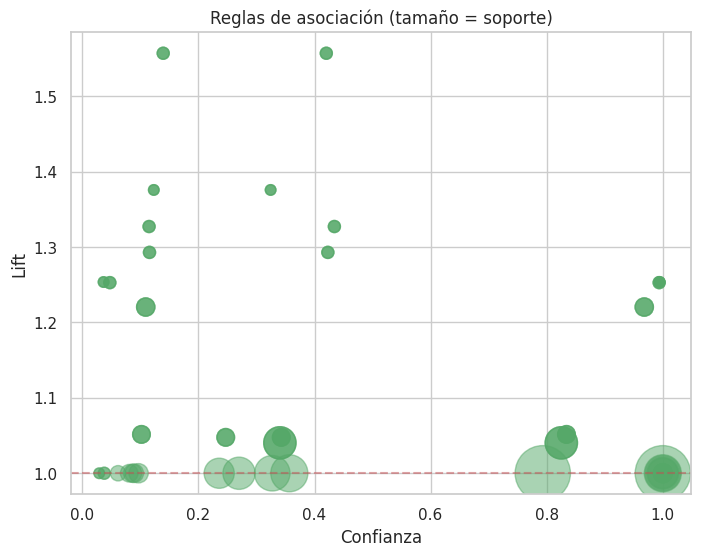

In [ ]:
# Visualización: confianza vs lift de las reglas
plt.figure(figsize=(8,6))
plt.scatter(reglas['confidence'], reglas['lift'], s=reglas['support']*2000, alpha=.5, c='#55A868')
plt.xlabel('Confianza'); plt.ylabel('Lift'); plt.title('Reglas de asociación (tamaño = soporte)')
plt.axhline(1, color='r', linestyle='--', alpha=.5); plt.show()

**ANÁLISIS — Reglas de oro:**

---
**reales más fuertes (top por lift):**
- `{Internet, TNT_Sport} → {TV, Telefonía}` — confianza 0.42, lift **1.56**
- `{TNT_Sport} → {Internet, Telefonía, TV}` — confianza 0.42, lift 1.56
- `{SVA, TV} → {TNT_Sport}` — confianza 0.32

**reglas a lenguaje de negocio:**
Las reglas obtenidas muestran que TNT Sports actúa como un servicio clave dentro de los paquetes contratados por los clientes. Quienes poseen Internet y TNT Sports suelen contratar también televisión y telefonía, mientras que los clientes con servicios de entretenimiento presentan una mayor tendencia a adquirir productos complementarios. Estos hallazgos permiten identificar oportunidades de venta cruzada y diseñar ofertas más atractivas para mejorar la fidelización y aumentar los ingresos.
_..._



---
# FASE 5 — Evaluación y Plan de Acción
**Insumos reales para el cierre:**
- Modelo con mejor ROC-AUC: Regresión Logística (0.637), con Recall 0.706.
- Clúster de mayor valor: el 0 (valor neto ~55.600). Clústeres nuevos de menor valor: 2 y 3.
- Regla ancla: Internet+TV+Telefonía aparecen fuertemente asociados (lift 1.56).

1. Modelo ganador y justificación de negocio

La Regresión Logística fue seleccionada como el mejor modelo debido a que obtuvo el mayor valor de ROC-AUC (0,637) y un Recall de 0,706, logrando un buen equilibrio entre capacidad predictiva y detección de clientes en riesgo. En este caso de negocio, es más costoso cometer un Falso Negativo (no detectar un cliente que abandonará la empresa) que un Falso Positivo, ya que la pérdida de un cliente implica una disminución directa de ingresos y una oportunidad perdida de retención. Por esta razón, se priorizó el Recall como métrica principal para la toma de decisiones.

2. Validación de hipótesis

La hipótesis H1 se confirma parcialmente, ya que los análisis muestran que los clientes con una mayor cantidad de reclamos presentan una tendencia superior al abandono. Por su parte, la hipótesis H2 se confirma, observándose que los clientes con menor antigüedad presentan mayores niveles de riesgo de abandono que aquellos con relaciones comerciales más prolongadas. Estos resultados coinciden con los patrones identificados durante el análisis exploratorio y la segmentación.

3. Plan de retención

Campaña 1: Retención de clientes Premium

Dirigida al Clúster 0, que presenta el mayor valor económico y la tasa de abandono más alta (5,82%).
Ofrecer beneficios exclusivos, descuentos por permanencia y atención preferencial para evitar la pérdida de clientes de alto valor.

Campaña 2: Fidelización temprana

Orientada a los clientes de los Clústeres 2 y 3, caracterizados por menor antigüedad y menor vinculación comercial.
Implementar promociones de permanencia, programas de bienvenida y ofertas de servicios complementarios durante los primeros meses de relación.

Campaña 3: Venta cruzada basada en Apriori

Aprovechar las reglas de asociación detectadas para ofrecer paquetes integrados de Internet, TV, Telefonía y TNT Sports.
Incrementar la cantidad de servicios contratados por cliente para fortalecer la relación comercial y reducir el riesgo de abandono.
4. Conclusiones

Los resultados obtenidos demuestran que las técnicas de minería de datos permiten identificar patrones relevantes asociados al abandono de clientes. La combinación de modelos predictivos, segmentación y reglas de asociación proporciona información valiosa para focalizar acciones comerciales y optimizar recursos de retención. Desde una perspectiva técnica y operativa, la implementación de estas soluciones es viable y puede generar beneficios significativos para Telcom, mejorando la fidelización, reduciendo el churn y aumentando la rentabilidad de la compañía.